**1. Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

**2. Load the Dataset**

In [3]:
dataset=pd.read_csv('dataset/jeddah_inventory_discrepancy_dataset.csv')
dataset


,Record_ID,Date,Day_Name,Is_Weekend,Month,Is_Peak_Season,Peak_Season_Type,AWB_Number,Cargo_Type,Cargo_Weight_KG,...,Movement_Count,Dwell_Time_Hours,Temperature_Sensitive,Damage_History,Missing_History,Inventory_Count_Difference,Warehouse_Utilization_Percent,Manual_Handling_Count,Audit_Flag,Inventory_Discrepancy
0,1,2023-04-01,Saturday,Yes,4,Yes,Ramadan,AWB-95822412,Pharma,120.5,...,6,5.9,Yes,No,No,3,93.6,2,Review Required,0
1,2,2023-04-01,Saturday,Yes,4,Yes,Ramadan,AWB-23756669,General Cargo,298.3,...,15,2.1,No,Yes,Yes,9,96.4,8,Review Required,1
2,3,2023-04-01,Saturday,Yes,4,Yes,Ramadan,AWB-90801586,Pharma,21.3,...,15,5.9,Yes,No,No,34,98.8,10,Review Required,0
3,4,2023-04-01,Saturday,Yes,4,Yes,Ramadan,AWB-39587039,Perishable,277.3,...,3,19.8,Yes,No,Yes,1,92.5,11,Passed,1
4,5,2023-04-01,Saturday,Yes,4,Yes,Ramadan,AWB-55667651,Perishable,221.4,...,7,10.4,Yes,No,No,13,93.9,12,Review Required,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30903,30904,2026-04-30,Thursday,No,4,No,Normal Operations,AWB-50102949,Automotive Parts,227.5,...,3,18.9,No,No,Yes,3,55.0,6,Review Required,0
30904,30905,2026-04-30,Thursday,No,4,No,Normal Operations,AWB-64646508,General Cargo,540.3,...,4,4.5,No,No,No,1,55.1,3,Passed,0
30905,30906,2026-04-30,Thursday,No,4,No,Normal Operations,AWB-33043441,Fashion,183.1,...,1,15.4,No,No,No,0,61.4,8,Passed,0
30906,30907,2026-04-30,Thursday,No,4,No,Normal Operations,AWB-68537437,Pharma,133.6,...,2,14.0,Yes,No,No,0,53.2,6,Review Required,0


In [ ]:
# Random Noise because the dataset was synethic so model perform overfitting
noise_idx = dataset.sample(
    frac=0.05,
    random_state=42
).index

# Flip Labels
dataset.loc[
    noise_idx,
    'Inventory_Discrepancy'
] = 1 - dataset.loc[
    noise_idx,
    'Inventory_Discrepancy'
]

**3. Basic Checkup**

In [371]:
#distribution of the target variable
dataset["Inventory_Discrepancy"].value_counts()

Inventory_Discrepancy
0    25750
1     5158
Name: count, dtype: int64

In [372]:
# Shape
print("Shape of the dataset:")
print(dataset.shape)
print("\n")


# Columns
print("Columns in the dataset:")
print(dataset.columns)

Shape of the dataset:
(30908, 26)


Columns in the dataset:
Index(['Record_ID', 'Date', 'Day_Name', 'Is_Weekend', 'Month',
       'Is_Peak_Season', 'Peak_Season_Type', 'AWB_Number', 'Cargo_Type',
       'Cargo_Weight_KG', 'Cargo_Volume_CBM', 'Handling_Complexity',
       'Storage_Zone', 'Shift', 'Worker_Experience_Years', 'Scan_Count',
       'Movement_Count', 'Dwell_Time_Hours', 'Temperature_Sensitive',
       'Damage_History', 'Missing_History', 'Inventory_Count_Difference',
       'Warehouse_Utilization_Percent', 'Manual_Handling_Count', 'Audit_Flag',
       'Inventory_Discrepancy'],
      dtype='str')


In [373]:
#check the null values in the dataset
dataset.isnull().sum()

Record_ID                        0
Date                             0
Day_Name                         0
Is_Weekend                       0
Month                            0
Is_Peak_Season                   0
Peak_Season_Type                 0
AWB_Number                       0
Cargo_Type                       0
Cargo_Weight_KG                  0
Cargo_Volume_CBM                 0
Handling_Complexity              0
Storage_Zone                     0
Shift                            0
Worker_Experience_Years          0
Scan_Count                       0
Movement_Count                   0
Dwell_Time_Hours                 0
Temperature_Sensitive            0
Damage_History                   0
Missing_History                  0
Inventory_Count_Difference       0
Warehouse_Utilization_Percent    0
Manual_Handling_Count            0
Audit_Flag                       0
Inventory_Discrepancy            0
dtype: int64

In [374]:
#information about the dataset
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 30908 entries, 0 to 30907
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Record_ID                      30908 non-null  int64  
 1   Date                           30908 non-null  str    
 2   Day_Name                       30908 non-null  str    
 3   Is_Weekend                     30908 non-null  str    
 4   Month                          30908 non-null  int64  
 5   Is_Peak_Season                 30908 non-null  str    
 6   Peak_Season_Type               30908 non-null  str    
 7   AWB_Number                     30908 non-null  str    
 8   Cargo_Type                     30908 non-null  str    
 9   Cargo_Weight_KG                30908 non-null  float64
 10  Cargo_Volume_CBM               30908 non-null  float64
 11  Handling_Complexity            30908 non-null  str    
 12  Storage_Zone                   30908 non-null  str    
 1

In [375]:
#statistical summary of the dataset
dataset.describe()

,Record_ID,Month,Cargo_Weight_KG,Cargo_Volume_CBM,Worker_Experience_Years,Scan_Count,Movement_Count,Dwell_Time_Hours,Inventory_Count_Difference,Warehouse_Utilization_Percent,Manual_Handling_Count,Inventory_Discrepancy
count,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000,30908.000000
mean,15454.500000,6.887472,291.603763,1.651639,10.015679,4.355895,6.497023,21.811162,6.256859,78.744073,8.202051,0.166882
std,8922.515396,3.330670,235.741994,1.186253,4.992351,2.279831,3.377294,22.052246,7.503366,13.725134,3.663929,0.372877
min,1.000000,1.000000,2.000000,0.007000,0.000000,1.000000,0.000000,1.000000,0.000000,33.700000,0.000000,0.000000
25%,7727.750000,4.000000,115.000000,0.639000,6.100000,3.000000,4.000000,6.600000,1.000000,71.200000,6.000000,0.000000
50%,15454.500000,7.000000,227.850000,1.400000,9.700000,4.000000,7.000000,14.700000,4.000000,81.800000,8.000000,0.000000
75%,23181.250000,10.000000,391.100000,2.529000,13.600000,6.000000,9.000000,29.300000,9.000000,89.000000,11.000000,0.000000
max,30908.000000,12.000000,999.900000,5.160000,24.600000,12.000000,15.000000,226.400000,50.000000,100.000000,20.000000,1.000000


**4. Exploratory Data Analysis**

4.1 Target Distribution

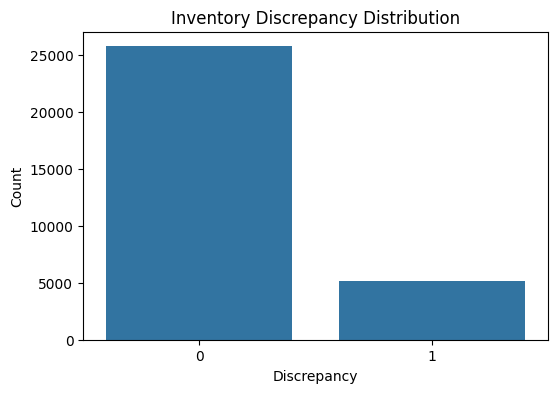

In [376]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Inventory_Discrepancy',
    data=dataset
)

plt.title("Inventory Discrepancy Distribution")
plt.xlabel("Discrepancy")
plt.ylabel("Count")

plt.show()

4.2 Shift vs Discrepancy

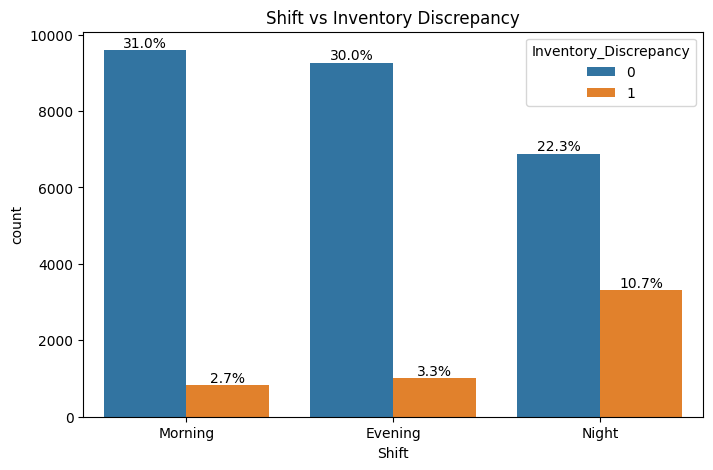

In [377]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Shift',
    hue='Inventory_Discrepancy',
    data=dataset
)

total = len(dataset)

# Add percentage labels
for p in ax.patches:
    
    height = p.get_height()
    
    # Skip empty bars
    if height > 0:
        
        percentage = f'{100 * height / total:.1f}%'
        
        x = p.get_x() + p.get_width() / 2
        y = height
        
        ax.annotate(
            percentage,
            (x, y),
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.title("Shift vs Inventory Discrepancy")
plt.show()

4.3 Handling Complexity vs Discrepancy

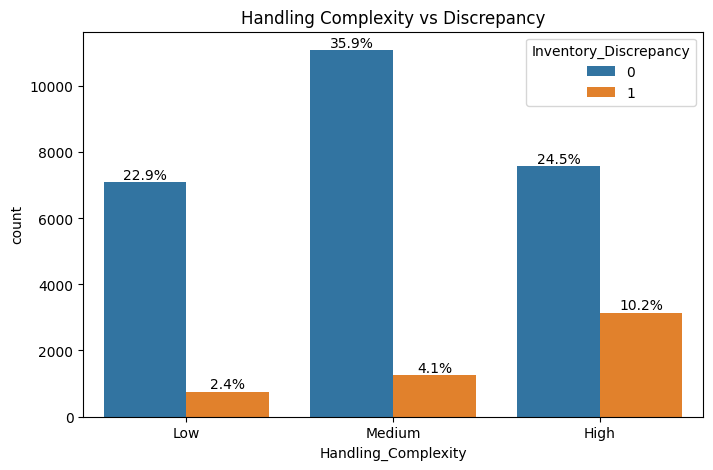

In [378]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Handling_Complexity',
    hue='Inventory_Discrepancy',
    data=dataset
)

total = len(dataset)

# Add percentage labels
for p in ax.patches:
    
    height = p.get_height()
    
    # Skip empty bars
    if height > 0:
        
        percentage = f'{100 * height / total:.1f}%'
        
        x = p.get_x() + p.get_width() / 2
        y = height
        
        ax.annotate(
            percentage,
            (x, y),
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Handling Complexity vs Discrepancy")

plt.show()

4.4 Dwell Time Distribution by Inventory Discrepancy

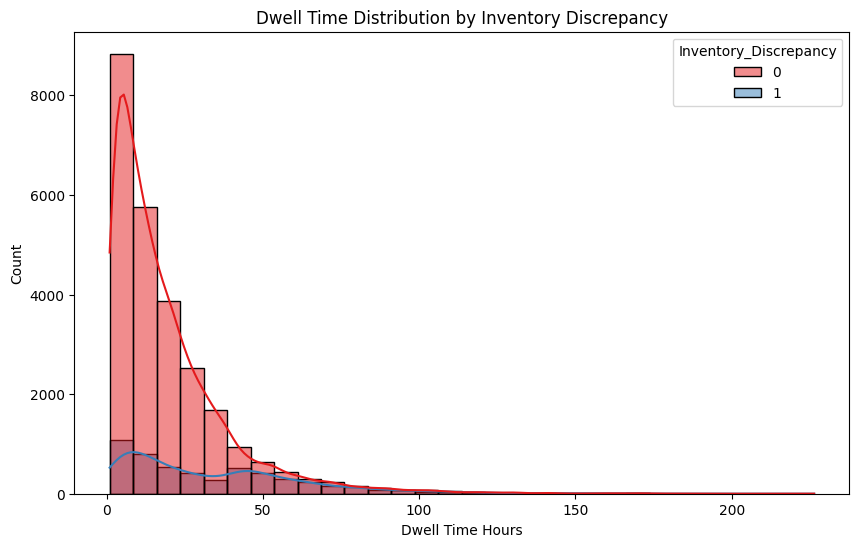

In [379]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=dataset,
    x='Dwell_Time_Hours',
    hue='Inventory_Discrepancy',
    bins=30,
    kde=True,
    palette='Set1'
)

plt.title("Dwell Time Distribution by Inventory Discrepancy")

plt.xlabel("Dwell Time Hours")
plt.ylabel("Count")

plt.show()

4.5 Discrepancy Rate by Month-Wise

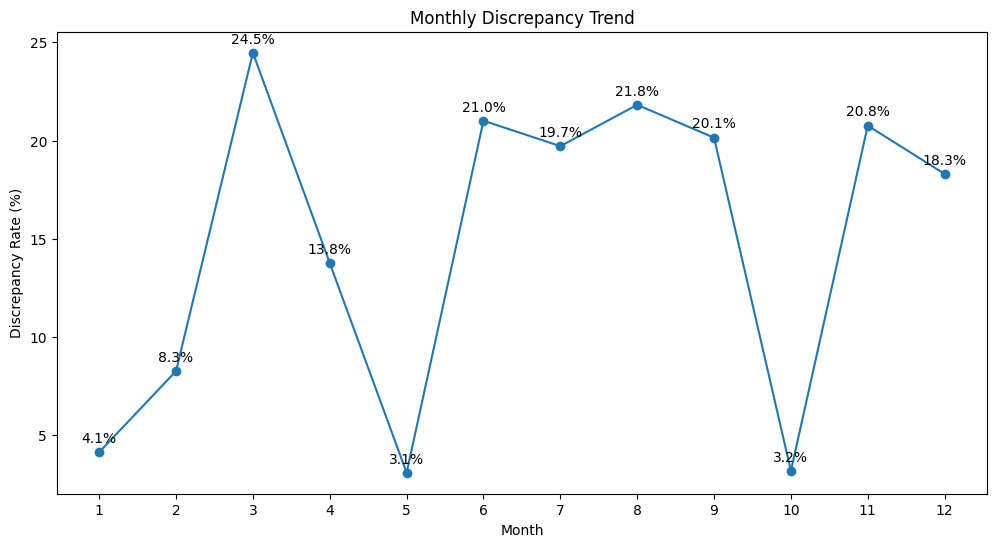

In [380]:
monthly_discrepancy = (
    dataset.groupby('Month')['Inventory_Discrepancy']
    .mean() * 100
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_discrepancy.index,
    monthly_discrepancy.values,
    marker='o'
)

# Show all months
plt.xticks(range(1,13))

# Add percentage labels
for x, y in zip(monthly_discrepancy.index, monthly_discrepancy.values):
    plt.text(
        x,
        y + 0.5,
        f"{y:.1f}%",
        ha='center'
    )

plt.title("Monthly Discrepancy Trend")
plt.xlabel("Month")
plt.ylabel("Discrepancy Rate (%)")

plt.show()

1. **Inventory Discrepancy Distribution :**
This chart shows the overall distribution of discrepancy and non-discrepancy records, helping identify class imbalance and overall inventory mismatch frequency.

2. **Shift vs Inventory Discrepancy :**
This visualization analyzes how different warehouse shifts influence inventory discrepancies and helps identify high-risk operational periods.

3. **Handling Complexity vs Inventory Discrepancy :**
This chart illustrates the relationship between cargo handling complexity and discrepancy occurrence, highlighting operational risk in complex handling scenarios.

4. **Distribution of Dwell Time :**
This histogram shows the distribution of cargo dwell time in the warehouse, helping detect delays, skewness, and operational bottlenecks.

5. **Monthly Discrepancy Trend :**
This line chart presents the monthly trend of inventory discrepancies, helping identify seasonal patterns and high-risk operational months.

**5. Feature Engineering**

5.1 Dataset Spliting

In [381]:
drop_columns=['Inventory_Discrepancy',
    'Record_ID',
    'AWB_Number',
    'Date',
    'Inventory_Count_Difference',
    'Audit_Flag']

# Features
X = dataset.drop(drop_columns, axis=1)

# Target
y = dataset['Inventory_Discrepancy']

# Check shape
print(X.shape)
print(y.shape)

(30908, 20)
(30908,)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

In [385]:
# Backup for CatBoost
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

In [ ]:
#categorical value for encoding
categorical_cols = X_train.select_dtypes(include='object').columns
print(categorical_cols)

NameError: name 'X_train' is not defined

5.2 Encoding the Categorical Values

In [387]:
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

encoder.fit(X_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [388]:
X_train_encoded = encoder.transform(
    X_train[categorical_cols]
)

X_val_encoded = encoder.transform(
    X_val[categorical_cols]
)

X_test_encoded = encoder.transform(
    X_test[categorical_cols]
)

In [389]:
encoded_feature_names = encoder.get_feature_names_out(
    categorical_cols
)

In [390]:
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_val_encoded_df = pd.DataFrame(
    X_val_encoded,
    columns=encoded_feature_names,
    index=X_val.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

In [ ]:
#numerical columns for Scaling
numerical_cols = X_train.select_dtypes(
    exclude='object'
).columns

X_train_num = X_train[numerical_cols]
X_val_num = X_val[numerical_cols]
X_test_num = X_test[numerical_cols]

NameError: name 'X_train' is not defined

In [ ]:
X_train_final = pd.concat(
    [X_train_num, X_train_encoded_df],
    axis=1
)

X_val_final = pd.concat(
    [X_val_num, X_val_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_num, X_test_encoded_df],
    axis=1
)
print(X_train_final.shape)
print(X_val_final.shape)
print(X_test_final.shape)

5.3 scaling the numerical_cols for logistic regression algorithm


In [395]:
scaler = StandardScaler()
scaler.fit(X_train_final)
X_train_scaled = scaler.transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

**6. Model Building**

6.1 Logistic Regression


In [396]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train_scaled,y_train)
y_prob_lr= lr_model.predict_proba(X_val_scaled)[:, 1]

threshold = 0.50

y_val_pred_lr = (y_prob_lr > threshold).astype(int)
print("Logistic Regression Model Trained Successfully")



Logistic Regression Model Trained Successfully


In [397]:
# Accuracy
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)

# Precision
lr_precision = precision_score(y_val, y_val_pred_lr)

# Recall
lr_recall = recall_score(y_val, y_val_pred_lr)

# F1 Score
lr_f1 = f1_score(y_val, y_val_pred_lr)

# Print metrics
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_lr))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lr))

Accuracy : 0.8252804141501294
Precision: 0.48695652173913045
Recall   : 0.8682170542635659
F1 Score : 0.6239554317548747

Confusion Matrix:

[[3154  708]
 [ 102  672]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.82      0.89      3862
           1       0.49      0.87      0.62       774

    accuracy                           0.83      4636
   macro avg       0.73      0.84      0.76      4636
weighted avg       0.89      0.83      0.84      4636



6.2 Decision tree 

In [398]:
# Initialize model
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

# Train model
dt_model.fit(X_train_final, y_train)

# Validation prediction
y_prob_dt = dt_model.predict_proba(X_val_scaled)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_dt = (y_prob_dt > threshold).astype(int)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


C:\Users\BalajiChitrarasu\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [399]:
# Accuracy
dt_accuracy = accuracy_score(y_val, y_val_pred_dt)

# Precision
dt_precision = precision_score(y_val, y_val_pred_dt)

# Recall
dt_recall = recall_score(y_val, y_val_pred_dt)

# F1 Score
dt_f1 = f1_score(y_val, y_val_pred_dt)

# Print metrics
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_dt))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_dt))

Accuracy : 0.296160483175151
Precision: 0.1600655558590549
Recall   : 0.7571059431524548
F1 Score : 0.26426155580608796

Confusion Matrix:

[[ 787 3075]
 [ 188  586]]

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.20      0.33      3862
           1       0.16      0.76      0.26       774

    accuracy                           0.30      4636
   macro avg       0.48      0.48      0.29      4636
weighted avg       0.70      0.30      0.32      4636



6.3 Random Forest


In [400]:
# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

# Train model
rf_model.fit(X_train_final, y_train)

# Validation prediction
y_prob_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_rf = (y_prob_rf > threshold).astype(int)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


C:\Users\BalajiChitrarasu\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [401]:
# Accuracy
rf_accuracy = accuracy_score(y_val, y_val_pred_rf)

# Precision
rf_precision = precision_score(y_val, y_val_pred_rf)

# Recall
rf_recall = recall_score(y_val, y_val_pred_rf)

# F1 Score
rf_f1 = f1_score(y_val, y_val_pred_rf)

# Print Metrics
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_rf))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_rf))

Accuracy : 0.8132010353753235
Precision: 0.4623567921440262
Recall   : 0.7299741602067183
F1 Score : 0.5661322645290581

Confusion Matrix:

[[3205  657]
 [ 209  565]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      3862
           1       0.46      0.73      0.57       774

    accuracy                           0.81      4636
   macro avg       0.70      0.78      0.72      4636
weighted avg       0.86      0.81      0.83      4636



6.4 XGBoost Algorithm

In [402]:
# xgb_params = {
#     'n_estimators': [100, 200,400],
#     'max_depth': [5,6,7, 10],
#     'learning_rate': [0.05, 0.1,0.5],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# # Base Model
# xgb_base = XGBClassifier(
#     random_state=42,
#     scale_pos_weight=4,
#     eval_metric='logloss',
#     n_jobs=-1
# )

# # GridSearch
# xgb_grid = GridSearchCV(
#     estimator=xgb_base,
#     param_grid=xgb_params,
#     scoring='f1',
#     cv=3,
#     n_jobs=-1,
#     verbose=1
# )

# # Train
# xgb_grid.fit(X_train_final, y_train)

# # Best Model
# best_xgb = xgb_grid.best_estimator_

# print("Best Parameters:", xgb_grid.best_params_)

# # Probability Prediction
# y_prob_xgb = best_xgb.predict_proba(X_val_final)[:, 1]

# # Threshold
# threshold = 0.45

# # Final Prediction
# y_val_pred_xgb = (y_prob_xgb > threshold).astype(int)

# print("XGBoost Model Trained Successfully")

In [403]:
# Tuned XGBoost with imbalance handling
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
)

# Train model
xgb_model.fit(X_train_final, y_train)

y_prob_xgb = xgb_model.predict_proba(X_val_final)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_xgb = (y_prob_xgb > threshold).astype(int)

print("Tuned XGBoost Model Trained Successfully")

Tuned XGBoost Model Trained Successfully


In [404]:
# Accuracy
xgb_accuracy = accuracy_score(y_val, y_val_pred_xgb)

# Precision
xgb_precision = precision_score(y_val, y_val_pred_xgb)

# Recall
xgb_recall = recall_score(y_val, y_val_pred_xgb)

# F1 Score
xgb_f1 = f1_score(y_val, y_val_pred_xgb)

# Print Metrics
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_xgb))

Accuracy : 0.9628990509059534
Precision: 0.9602446483180428
Recall   : 0.8113695090439277
F1 Score : 0.8795518207282913

Confusion Matrix:

[[3836   26]
 [ 146  628]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3862
           1       0.96      0.81      0.88       774

    accuracy                           0.96      4636
   macro avg       0.96      0.90      0.93      4636
weighted avg       0.96      0.96      0.96      4636



6.5 lightGBM


In [405]:
# Initialize model
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42
)
# Train model
lgbm_model.fit(X_train_final, y_train)

# Predict probabilities
y_prob_lgbm = lgbm_model.predict_proba(X_val_final)[:, 1]

# Custom threshold
threshold = 0.50

# Apply threshold
y_val_pred_lgbm = (y_prob_lgbm > threshold).astype(int)


print("LightGBM Model Trained Successfully")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3610, number of negative: 18025
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1408
[LightGBM] [Info] Number of data points in the train set: 21635, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [406]:
# Accuracy
lgbm_accuracy = accuracy_score(y_val, y_val_pred_lgbm)

# Precision
lgbm_precision = precision_score(y_val, y_val_pred_lgbm)

# Recall
lgbm_recall = recall_score(y_val, y_val_pred_lgbm)

# F1 Score
lgbm_f1 = f1_score(y_val, y_val_pred_lgbm)

# Print Metrics
print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred_lgbm))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_lgbm))

Accuracy : 0.9432700603968939
Precision: 0.81044957472661
Recall   : 0.8617571059431525
F1 Score : 0.8353162179085786

Confusion Matrix:

[[3706  156]
 [ 107  667]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      3862
           1       0.81      0.86      0.84       774

    accuracy                           0.94      4636
   macro avg       0.89      0.91      0.90      4636
weighted avg       0.94      0.94      0.94      4636



**7. Model Comparision**

In [ ]:
# Create Model Comparison Table

model_results = pd.DataFrame({
    'Model': ['Logistic Regression','Decision Tree','Random Forest','XGBoost','LightGBM'],
    'Accuracy': [lr_accuracy,dt_accuracy,rf_accuracy,xgb_accuracy,lgbm_accuracy],
    'Precision': [lr_precision,dt_precision,rf_precision, xgb_precision,lgbm_precision],
    'Recall': [lr_recall, dt_recall, rf_recall, xgb_recall, lgbm_recall],
    'F1 Score': [lr_f1, dt_f1, rf_f1, xgb_f1,lgbm_f1]
})

# Sort by F1 Score
model_results = model_results.sort_values(
    by='F1 Score',
    ascending=False
)

# Display
print(model_results)

                 Model  Accuracy  Precision    Recall  F1 Score
3              XGBoost  0.962899   0.960245  0.811370  0.879552
4             LightGBM  0.943270   0.810450  0.861757  0.835316
0  Logistic Regression  0.825280   0.486957  0.868217  0.623955
2        Random Forest  0.813201   0.462357  0.729974  0.566132
1        Decision Tree  0.296160   0.160066  0.757106  0.264262


**8. Testing the Final Model**

In [423]:
# Probability Prediction
y_prob_test_xgb = xgb_model.predict_proba(
    X_test_final
)[:, 1]

# Threshold
threshold = 0.50

# Final Prediction
y_test_pred_xgb = (
    y_prob_test_xgb > threshold
).astype(int)

print("LightGBM Test Prediction Completed")

LightGBM Test Prediction Completed


In [424]:
# Accuracy
test_accuracy = accuracy_score(y_test,y_test_pred_xgb)

# Precision
test_precision = precision_score(y_test,y_test_pred_xgb)

# Recall
test_recall = recall_score(y_test,y_test_pred_xgb)

# F1 Score
test_f1 = f1_score(y_test, y_test_pred_xgb)

# Print Metrics
print("Accuracy :", test_accuracy)
print("Precision:", test_precision)
print("Recall   :", test_recall)
print("F1 Score :", test_f1)

# Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test,y_test_pred_xgb))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test,y_test_pred_xgb))

Accuracy : 0.9622600819495364
Precision: 0.9544764795144158
Recall   : 0.8126614987080103
F1 Score : 0.8778785764131193
Confusion Matrix:

[[3833   30]
 [ 145  629]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      3863
           1       0.95      0.81      0.88       774

    accuracy                           0.96      4637
   macro avg       0.96      0.90      0.93      4637
weighted avg       0.96      0.96      0.96      4637



**9. Save the Model**

In [429]:
import joblib

# Save LightGBM Model
joblib.dump(
    xgb_model,
    'model/xgboost_inventory_model.pkl'
)

# Save Encoder
joblib.dump(
    encoder,
    'model/encoder.pkl'
)

# Save Scaler
joblib.dump(
    scaler,
    'model/scaler.pkl'
)

# Save Training Columns
joblib.dump(
    X_train_final.columns.tolist(),
    'model/model_columns.pkl'
)

print("Model Files Saved Successfully")

Model Files Saved Successfully


**10. Feature Importance**

In [428]:
# Create Feature Importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_model.feature_importances_
})

# Convert to Percentage
feature_importance['Importance_Percentage'] = (
    feature_importance['Importance']/
    feature_importance['Importance'].sum()
) * 100

# Sort Values
feature_importance = feature_importance.sort_values(
    by='Importance_Percentage',
    ascending=False
)

# Round Values
feature_importance['Importance_Percentage'] = (
    feature_importance['Importance_Percentage']
    .round(2)
)

# Display
print(
    feature_importance[
        ['Feature', 'Importance_Percentage']
    ].head(20)
)

                          Feature  Importance_Percentage
19             Is_Peak_Season_Yes                  10.35
46                    Shift_Night                   8.69
52            Missing_History_Yes                   6.11
35       Handling_Complexity_High                   6.00
7   Warehouse_Utilization_Percent                   4.86
51             Missing_History_No                   4.85
16                  Is_Weekend_No                   4.55
6                Dwell_Time_Hours                   4.41
17                 Is_Weekend_Yes                   4.35
49              Damage_History_No                   4.06
37     Handling_Complexity_Medium                   2.91
50             Damage_History_Yes                   2.89
45                  Shift_Morning                   2.86
44                  Shift_Evening                   2.18
4                      Scan_Count                   2.04
48      Temperature_Sensitive_Yes                   2.03
18              Is_Peak_Season_